In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.environ['TF_USE_LEGACY_KERAS'] = '1'
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.callbacks import EarlyStopping

import keras

from sklearn.utils.class_weight import compute_class_weight

assert tf.__version__.startswith('2'), f'TF 2.x required, got {tf.__version__}'
print(f'TensorFlow:     {tf.__version__}')
print(f'Keras:          {keras.__version__}')
print(f'TF Hub:         {hub.__version__}')
print(f'GPUs available: {tf.config.list_physical_devices("GPU")}')

TensorFlow:     2.21.0
Keras:          3.14.1
TF Hub:         0.16.1
GPUs available: []


In [24]:
DATA_DIR = './images'

EFFNET_LITE0_URL    = 'https://tfhub.dev/tensorflow/efficientnet/lite0/feature-vector/2'
ESTIMATE_IMAGE_SIZE = (224, 224)  
BATCH_SIZE          = 32
ESTIMATOR_EPOCHS    = 5
SEED                = 42

# Silva used 80/10/10 Train / val / test split 
VAL_FRACTION  = 0.10
TEST_FRACTION = 0.10

## Data Prep

In [25]:
# Sanity check the directory exists and list the bin folders found
assert os.path.isdir(DATA_DIR), f'DATA_DIR not found: {DATA_DIR}'
subdirs = sorted(d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d)))
print(f'Found {len(subdirs)} class folders in {DATA_DIR}:')
for d in subdirs:
    n = len([f for f in os.listdir(os.path.join(DATA_DIR, d))
             if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    print(f'  {d:<12} {n:>5} images')

Found 10 class folders in ./images:
  class10         20 images
  class15         20 images
  class20         20 images
  class25         20 images
  class30         20 images
  class35         20 images
  class40         20 images
  class50         20 images
  class60         20 images
  class70         22 images


In [26]:
# Load the images as a single dataset
full_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode='int',
    image_size=ESTIMATE_IMAGE_SIZE,
    batch_size=None,
    shuffle=True,
    seed=SEED,
)

BIN_LABELS    = full_ds.class_names                 
NUM_SIZE_BINS = len(BIN_LABELS)
print(f'\nClass names: {BIN_LABELS}')
print(f'Num classes: {NUM_SIZE_BINS}')

total = sum(1 for _ in full_ds)
print(f'Total images: {total}')

Found 202 files belonging to 10 classes.

Class names: ['class10', 'class15', 'class20', 'class25', 'class30', 'class35', 'class40', 'class50', 'class60', 'class70']
Num classes: 10
Total images: 202


In [27]:
n_val   = int(total * VAL_FRACTION)
n_test  = int(total * TEST_FRACTION)
n_train = total - n_val - n_test

train_ds_raw = full_ds.take(n_train)
rest_ds      = full_ds.skip(n_train)
val_ds_raw   = rest_ds.take(n_val)
test_ds_raw  = rest_ds.skip(n_val)

print(f'Train: {n_train}  Val: {n_val}  Test: {n_test}')

# Check data distribution
y_train = np.array([int(label.numpy()) for _, label in train_ds_raw])
print(f'Train label distribution: {np.bincount(y_train, minlength=NUM_SIZE_BINS)}')

Train: 162  Val: 20  Test: 20
Train label distribution: [17 15 16 19 16 14 14 17 20 14]


In [28]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (train_ds_raw
            .shuffle(1000, seed=SEED)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))
val_ds   = val_ds_raw.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)
test_ds  = test_ds_raw.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)

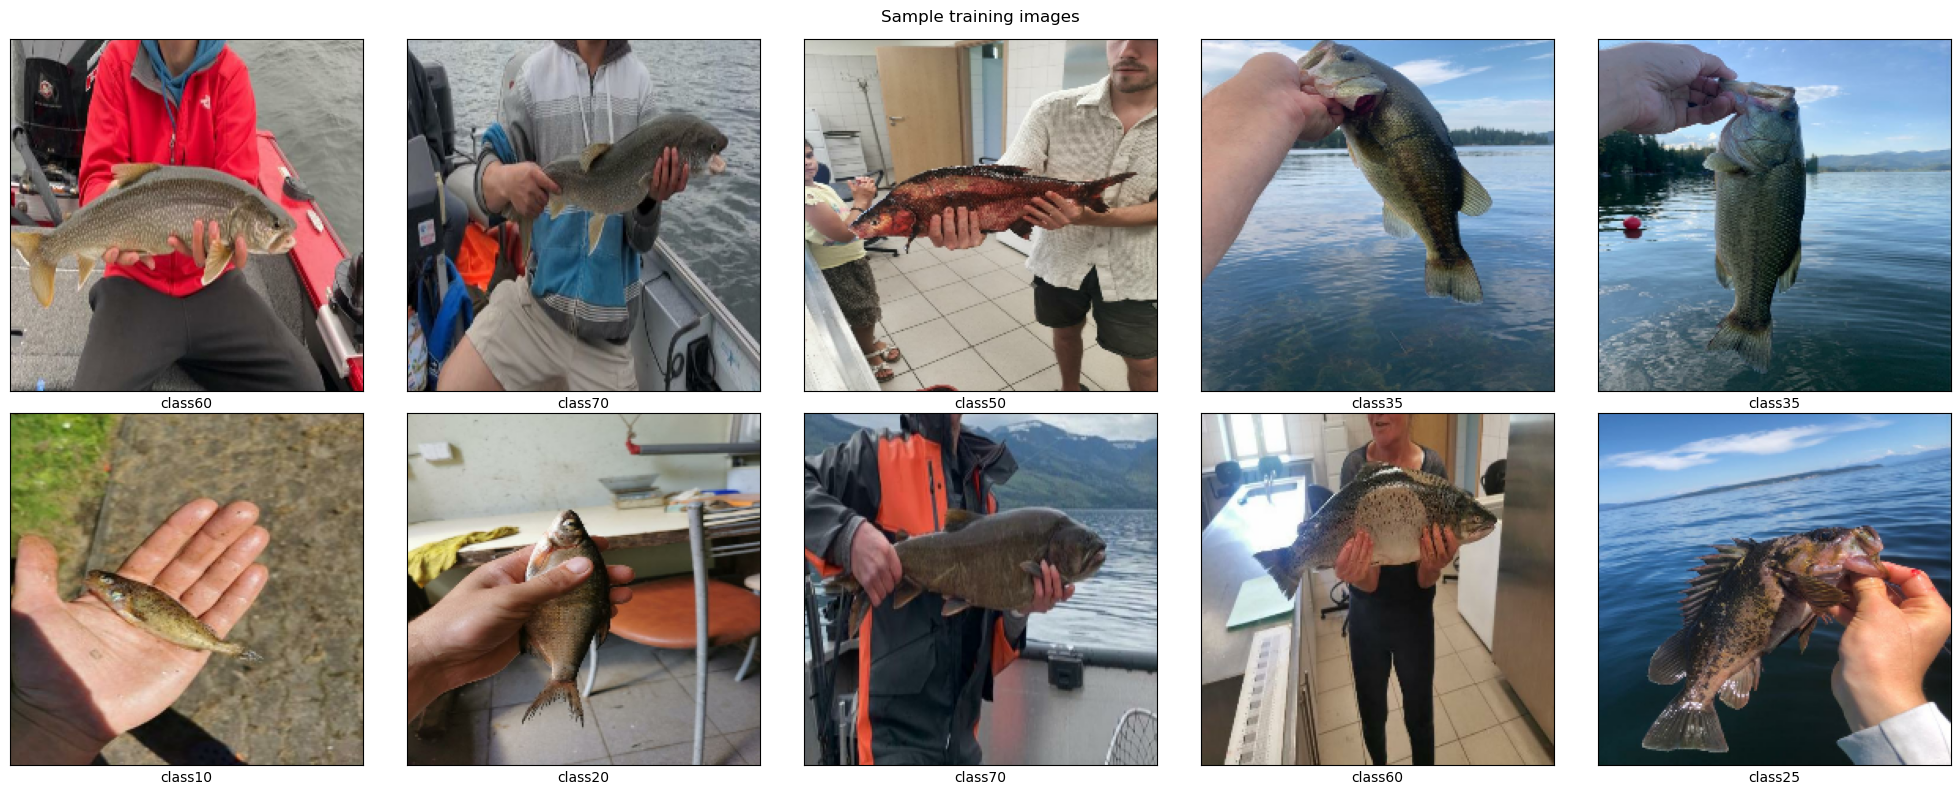

In [29]:
# Preview a few training images
plt.figure(figsize=(20, 8))
for imgs, lbls in train_ds.take(1):
    for i in range(min(10, imgs.shape[0])):
        plt.subplot(2, 5, i + 1)
        plt.xticks([]); plt.yticks([]); plt.grid(False)
        plt.imshow(imgs[i].numpy().astype('uint8'))
        plt.xlabel(BIN_LABELS[lbls[i].numpy()])
plt.suptitle('Sample training images')
plt.tight_layout(); plt.show()

## Build the Model

In [30]:
def build_estimator(num_classes, trainable_backbone=False):
    backbone = hub.KerasLayer(
        EFFNET_LITE0_URL,
        trainable=trainable_backbone,
        input_shape=ESTIMATE_IMAGE_SIZE + (3,),
    )
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=ESTIMATE_IMAGE_SIZE + (3,)),
        tf.keras.layers.Rescaling(1.0 / 255.0),   # [0,255] → [0,1] for Lite0
        backbone,                                  
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation='softmax'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

estimator = build_estimator(NUM_SIZE_BINS, trainable_backbone=False)
estimator.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_2 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 keras_layer_2 (KerasLayer)  (None, 1280)              3413024   
                                                                 
 dropout_2 (Dropout)         (None, 1280)              0         
                                                                 
 dense_2 (Dense)             (None, 10)                12810     
                                                                 
Total params: 3425834 (13.07 MB)
Trainable params: 12810 (50.04 KB)
Non-trainable params: 3413024 (13.02 MB)
_________________________________________________________________


## Train

In [ ]:
# Class weights to handle bin imbalance
unique_bins = np.unique(y_train)
weights_arr = compute_class_weight('balanced', classes=unique_bins, y=y_train)
class_weights = dict(zip(unique_bins.tolist(), weights_arr.tolist()))

early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

history = estimator.fit(
    train_ds,
    validation_data=val_ds,
    epochs=ESTIMATOR_EPOCHS
    
    # Options below were not used in the orignal paper but do improve accuracy
    #class_weight=class_weights,
    #callbacks=[early_stop],
)

Epoch 1/5
6/6 [==============================] - 2s 138ms/step - loss: 2.4193 - accuracy: 0.1296 - val_loss: 2.0526 - val_accuracy: 0.2000
Epoch 2/5
6/6 [==============================] - 1s 91ms/step - loss: 2.1173 - accuracy: 0.3086 - val_loss: 1.8618 - val_accuracy: 0.3500
Epoch 3/5
6/6 [==============================] - 1s 89ms/step - loss: 1.8901 - accuracy: 0.3642 - val_loss: 1.7030 - val_accuracy: 0.4000
Epoch 4/5
6/6 [==============================] - 1s 88ms/step - loss: 1.7300 - accuracy: 0.4259 - val_loss: 1.6236 - val_accuracy: 0.4500
Epoch 5/5
6/6 [==============================] - 1s 93ms/step - loss: 1.6129 - accuracy: 0.4568 - val_loss: 1.5573 - val_accuracy: 0.5500


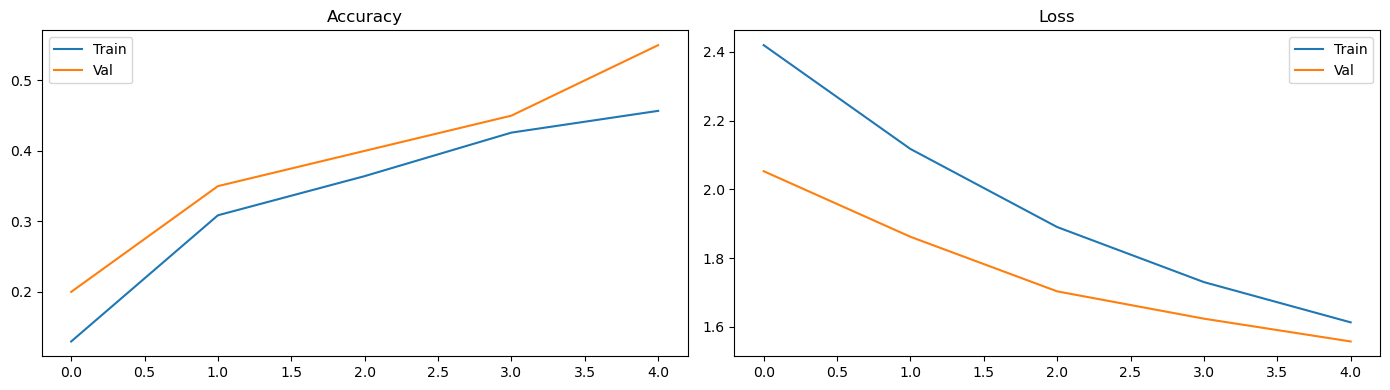

Train  — loss: 1.5091, accuracy: 56.79%
Val    — loss: 1.5573, accuracy: 55.00%
Test   — loss: 1.4350, accuracy: 65.00%


In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy'); ax1.legend()
ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss'); ax2.legend()
plt.tight_layout(); plt.show()

for ds, name in [(train_ds, 'Train'), (val_ds, 'Val'), (test_ds, 'Test')]:
    loss, acc = estimator.evaluate(ds, verbose=0)
    print(f'{name:<6} — loss: {loss:.4f}, accuracy: {acc:.2%}')

## Confusion matrix

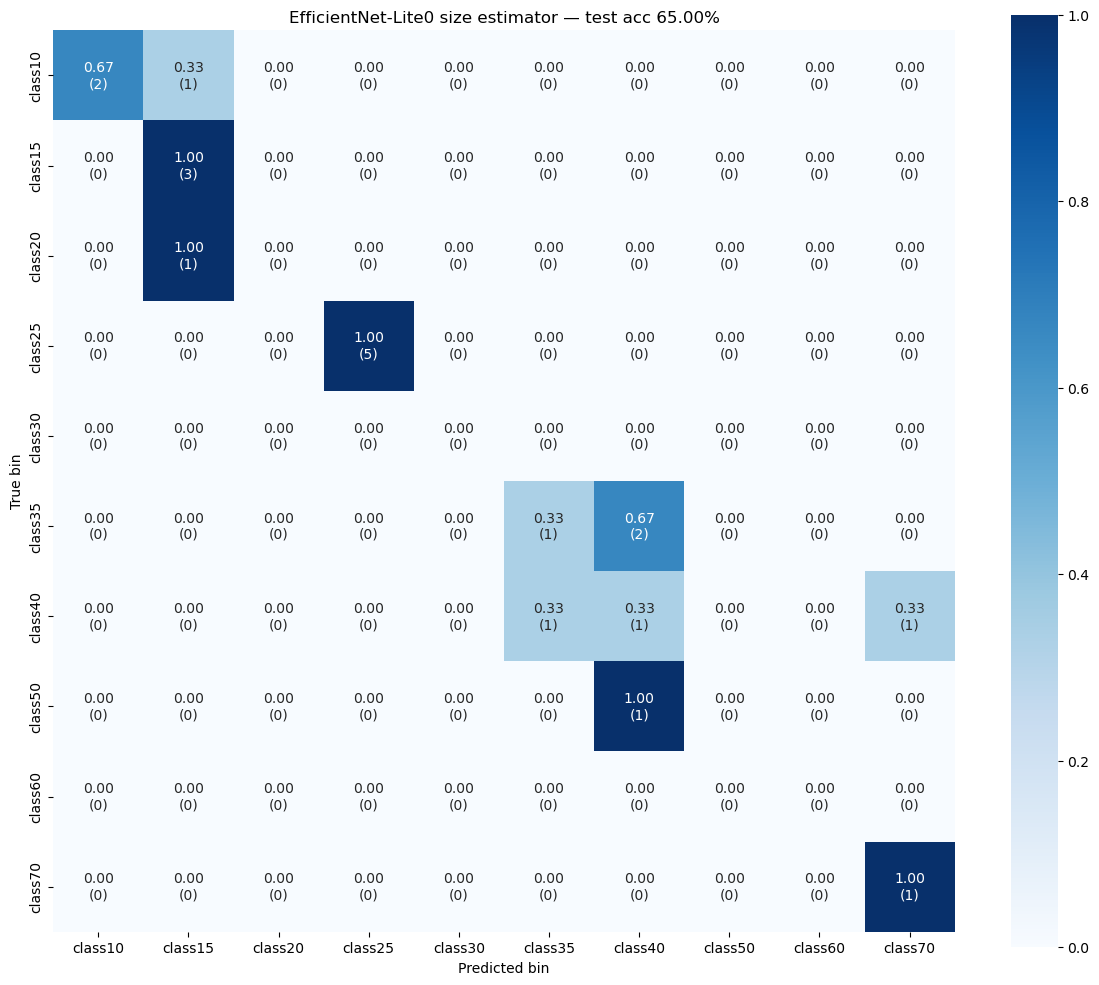

In [33]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Gather true labels and predictions over the test set
y_true, y_pred = [], []
for imgs, lbls in test_ds:
    probs = estimator.predict(imgs, verbose=0)
    y_pred.append(np.argmax(probs, axis=1))
    y_true.append(lbls.numpy())
y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

cm      = confusion_matrix(y_true, y_pred, labels=list(range(NUM_SIZE_BINS)))
row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.where(row_sum == 0, 0, cm.astype('float') / np.where(row_sum == 0, 1, row_sum))
annot   = np.array([[f'{cm_norm[i,j]:.2f}\n({cm[i,j]})' for j in range(NUM_SIZE_BINS)]
                     for i in range(NUM_SIZE_BINS)])

test_acc = np.mean(y_true == y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, xticklabels=BIN_LABELS, yticklabels=BIN_LABELS,
            cmap='Blues', annot=annot, fmt='', square=True, vmin=0, vmax=1)
plt.title(f'EfficientNet-Lite0 size estimator — test acc {test_acc:.2%}')
plt.ylabel('True bin'); plt.xlabel('Predicted bin')
plt.tight_layout(); plt.show()